In [1]:
import os
import random
import sys
import cv2
import tqdm
import json
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [2]:
!pip install polars seaborn

import polars as pl

In [3]:
!nvidia-smi

Wed Jan 28 07:06:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 570.211.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A5000               On  |   00000000:CE:00.0 Off |                  Off |
| 30%   29C    P8             23W /  230W |       1MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import os
os.chdir('/workspace')

In [5]:
df = pl.read_csv("vindr_mammogram/mammo_processed_merged1/mammo_processed_merged.csv")
df = df.to_pandas()
df["merged_image_path"] = (
    df["merged_image_path"]
    .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
    .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
)

In [6]:
df['cc_finding_categories'].value_counts().sort_index()

cc_finding_categories
['Architectural Distortion', 'Mass']                                                                   1
['Architectural Distortion']                                                                          40
['Asymmetry', 'Mass']                                                                                  1
['Asymmetry']                                                                                         20
['Focal Asymmetry']                                                                                  107
['Global Asymmetry']                                                                                  11
['Mass']                                                                                             443
['Nipple Retraction', 'Mass']                                                                          1
['Nipple Retraction', 'Skin Thickening', 'Mass']                                                       1
['Nipple Retraction']            

In [7]:
def get_combined_finding_6class(cc_findings, mlo_findings, cc_birads, mlo_birads):
    if isinstance(cc_findings, str):
        cc_findings = eval(cc_findings) if cc_findings else []
    if isinstance(mlo_findings, str):
        mlo_findings = eval(mlo_findings) if mlo_findings else []
    
    cc_findings = cc_findings or []
    mlo_findings = mlo_findings or []
    all_findings = set(cc_findings + mlo_findings)
    
    if len(all_findings) > 1 and 'No Finding' in all_findings:
        all_findings.remove('No Finding')
    
    high_suspicion_structural = {
        'Architectural Distortion',
        'Skin Thickening',
        'Skin Retraction',
        'Nipple Retraction'
    }
    
    asymmetry_findings = {
        'Focal Asymmetry',
        'Global Asymmetry',
        'Asymmetry'
    }
    
    has_mass = 'Mass' in all_findings
    has_calc = 'Suspicious Calcification' in all_findings
    has_structural = bool(all_findings & high_suspicion_structural)
    has_asymmetry = bool(all_findings & asymmetry_findings)
    has_lymph = 'Suspicious Lymph Node' in all_findings
    
    def parse_birads(birads_str):
        if pd.isna(birads_str) or birads_str == '':
            return 0
        if isinstance(birads_str, str):
            try:
                return int(birads_str.strip().split()[-1])
            except:
                return 0
        return int(birads_str)
    
    cc_birads_num = parse_birads(cc_birads)
    mlo_birads_num = parse_birads(mlo_birads)
    max_birads = max(cc_birads_num, mlo_birads_num)
    
    if not all_findings or all_findings == {'No Finding'}:
        if max_birads == 1:
            return 0
        elif max_birads == 2:
            return 1
        else:
            return 1 if max_birads == 3 else 4
    
    if has_structural:
        return 4
    
    if has_mass and has_calc:
        return 3
    
    if has_mass:
        return 3
    
    if has_calc:
        return 2
    
    if has_lymph:
        return 4
    
    if has_asymmetry and len(all_findings) == 1:
        return -1
    
    if has_asymmetry and len(all_findings) > 1:
        return 4
    
    print(f"Warning: Unknown finding combination: {all_findings}, BIRADS: {max_birads}")
    return 4

df['finding'] = df.apply(
    lambda row: get_combined_finding_6class(
        row['cc_finding_categories'], 
        row['mlo_finding_categories'],
        row['cc_breast_birads'],
        row['mlo_breast_birads']
    ),
    axis=1
)
df.drop(df[df['finding'] == -1].index, inplace=True)
df['finding'].value_counts().sort_index()

finding
0    6703
1    2329
2     132
3     551
4      95
Name: count, dtype: int64

In [8]:
inbreast_df = pd.read_csv("inbreast_data/INbreast_merged/merged_metadata.csv")
inbreast_df["merged_image_path"] = (
    inbreast_df["merged_image_path"]
    .str.replace("INbreast Release 1.0", "inbreast_data", regex=False)
    .str.replace("vindr_original_data", "inbreast_data", regex=False))
inbreast_df['birads'] = inbreast_df['birads'].replace({'4a': '4', '4b': '4', '4c': '4','6':'5'})
inbreast_df['label'] = (inbreast_df['birads'].astype(int) - 1).astype(int)
inbreast_df.head()

,patient_id,laterality,merged_image_path,cc_file_name,mlo_file_name,cc_image_path,mlo_image_path,birads,cc_roi_width,cc_roi_height,mlo_roi_width,mlo_roi_height,label
0,024ee3569b2605dc,L,inbreast_data/INbreast_merged/024ee3569b2605dc...,20588020,20588072,INbreast Release 1.0/INbreast_processed/205880...,INbreast Release 1.0/INbreast_processed/205880...,2,1557,3231,1674,3192,1
1,024ee3569b2605dc,R,inbreast_data/INbreast_merged/024ee3569b2605dc...,20587994,20588046,INbreast Release 1.0/INbreast_processed/205879...,INbreast Release 1.0/INbreast_processed/205880...,5,1535,3128,1775,3199,4
2,069212ec65a94339,L,inbreast_data/INbreast_merged/069212ec65a94339...,50994787,50994733,INbreast Release 1.0/INbreast_processed/509947...,INbreast Release 1.0/INbreast_processed/509947...,1,1226,2580,1340,3193,0
3,069212ec65a94339,R,inbreast_data/INbreast_merged/069212ec65a94339...,50994706,50994760,INbreast Release 1.0/INbreast_processed/509947...,INbreast Release 1.0/INbreast_processed/509947...,1,1128,2566,1177,3195,0
4,0b7396cdccacca82,L,inbreast_data/INbreast_merged/0b7396cdccacca82...,22670832,22670878,INbreast Release 1.0/INbreast_processed/226708...,INbreast Release 1.0/INbreast_processed/226708...,2,1627,2983,1598,3170,1


In [9]:
inbreast_df['label'].value_counts()

label
1    98
0    30
4    28
3    20
2    11
Name: count, dtype: int64

In [10]:
def birads_to_label(birads_category):
    """Convert BI-RADS categories to numerical labels 0-4 (for 5 classes)"""
    birads_num = int(birads_category.replace(" ", "")[-1])
    return birads_num - 1
df['label'] = df['cc_breast_birads'].apply(birads_to_label)

In [11]:
df['label'].value_counts()

label
0    6703
1    2337
3     339
2     319
4     112
Name: count, dtype: int64

In [12]:
df['cc_breast_density'].value_counts()

cc_breast_density
DENSITY C    7486
DENSITY D    1335
DENSITY B     942
DENSITY A      47
Name: count, dtype: int64

In [13]:
data = df[df['split'] == 'training']
test_df = df[df['split'] == 'test']

In [14]:
from sklearn.model_selection import train_test_split


study_meta = (
    data
    .groupby('study_id')
    .agg({
        'cc_breast_birads': 'first',   # BI-RADS at study level
        'finding': 'first'             # finding already encoded as 0–4
    })
    .reset_index()
)


# -------------------------------------------------
study_meta['stratify_key'] = (
    study_meta['cc_breast_birads'].astype(str) + '_' +
    study_meta['finding'].astype(str)
)


train_studies, val_studies = train_test_split(
    study_meta['study_id'],
    test_size=0.1,
    stratify=study_meta['stratify_key'],
    random_state=423
)

train_df = data[data['study_id'].isin(train_studies)].copy()
val_df   = data[data['study_id'].isin(val_studies)].copy()


In [15]:
train_df.shape

(7057, 26)

In [16]:
import numpy as np
import cv2
from PIL import Image
import torchvision.transforms as transforms
import random
import torch


def get_transforms(img_size=(512, 512)):
    """Enhanced mammogram preprocessing with medical imaging considerations"""
    
    train_transform = transforms.Compose([
        transforms.Resize(img_size, interpolation=transforms.InterpolationMode.BICUBIC),
        
        transforms.RandomApply([
            transforms.RandomAffine(
                degrees=10,
                translate=(0.1, 0.1),
                scale=(0.9, 1.1),
                shear=6
            )
        ], p=0.6),
        
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomApply([
            transforms.RandomPerspective(distortion_scale=0.1, p=1.0)
        ], p=0.1),
        
        transforms.RandomApply([
            transforms.ElasticTransform(alpha=5.0, sigma=3.0)
        ], p=0.2),
        transforms.RandomApply([
            transforms.ColorJitter(
                brightness=(0.95, 1.05),
                contrast=(0.9, 1.1)
            )
        ], p=0.4),
        transforms.Lambda(lambda x: adjust_gamma(x, gamma=random.uniform(0.8, 1.2)) 
                         if random.random() < 0.4 else x),
        

        
        transforms.RandomApply([
            transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))
        ], p=0.2),
        
                # NOISE AUGMENTATIONS
        transforms.Lambda(lambda x: add_gaussian_noise(x, mean=0, std=random.uniform(0.001, 0.02)) 
                         if random.random() < 0.4 else x),
        
        transforms.Lambda(lambda x: add_speckle_noise(x, std=random.uniform(0.01, 0.03)) 
                         if random.random() < 0.2 else x),
        transforms.ToTensor(),
        
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize(img_size, interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    return train_transform, val_transform

def add_gaussian_noise(image, mean=0, std=0.02):
    """Gaussian noise - electronic noise in imaging sensors"""
    if isinstance(image, Image.Image):
        img_array = np.array(image).astype(np.float32) / 255.0
        noise = np.random.normal(mean, std, img_array.shape)
        noisy_img = np.clip(img_array + noise, 0, 1)
        return Image.fromarray((noisy_img * 255).astype(np.uint8))
    return image


def adjust_gamma(image, gamma=1.0):
    """
    Gamma correction - handles tissue density variation
    Gamma < 1 = brighter, > 1 = darker
    """
    if isinstance(image, Image.Image):
        img_array = np.array(image).astype(np.float32) / 255.0
        gamma_corrected = np.power(img_array, gamma)
        return Image.fromarray((gamma_corrected * 255).astype(np.uint8))
    return image

In [17]:
import numpy as np
import cv2
from PIL import Image
import torchvision.transforms as transforms
import random
import torch


def get_transforms(img_size=(512, 512)):
    """Enhanced mammogram preprocessing with medical imaging considerations"""
    
    train_transform = transforms.Compose([
        transforms.Resize(img_size, interpolation=transforms.InterpolationMode.BICUBIC),
        
        transforms.RandomApply([
            transforms.RandomAffine(
                degrees=10,
                translate=(0.1, 0.1),
                scale=(0.9, 1.1),
                shear=6
            )
        ], p=0.6),
        
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomApply([
            transforms.RandomPerspective(distortion_scale=0.1, p=1.0)
        ], p=0.1),
        
        transforms.RandomApply([
            transforms.ElasticTransform(alpha=5.0, sigma=3.0)
        ], p=0.2),
        transforms.RandomApply([
            transforms.ColorJitter(
                brightness=(0.95, 1.05),
                contrast=(0.9, 1.1)
            )
        ], p=0.4),
        transforms.Lambda(lambda x: adjust_gamma(x, gamma=random.uniform(0.8, 1.2)) 
                         if random.random() < 0.4 else x),
        

        
        transforms.RandomApply([
            transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))
        ], p=0.2),
        
                # NOISE AUGMENTATIONS
        transforms.Lambda(lambda x: add_gaussian_noise(x, mean=0, std=random.uniform(0.001, 0.02)) 
                         if random.random() < 0.4 else x),
        
        transforms.Lambda(lambda x: add_speckle_noise(x, std=random.uniform(0.01, 0.03)) 
                         if random.random() < 0.2 else x),
        transforms.ToTensor(),
        
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize(img_size, interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    return train_transform, val_transform

def add_gaussian_noise(image, mean=0, std=0.02):
    """Gaussian noise - electronic noise in imaging sensors"""
    if isinstance(image, Image.Image):
        img_array = np.array(image).astype(np.float32) / 255.0
        noise = np.random.normal(mean, std, img_array.shape)
        noisy_img = np.clip(img_array + noise, 0, 1)
        return Image.fromarray((noisy_img * 255).astype(np.uint8))
    return image


def add_speckle_noise(image, std=0.03):
    """Speckle noise - multiplicative noise common in mammography"""
    if isinstance(image, Image.Image):
        img_array = np.array(image).astype(np.float32) / 255.0
        noise = np.random.normal(0, std, img_array.shape)
        noisy_img = img_array + img_array * noise
        return Image.fromarray((np.clip(noisy_img, 0, 1) * 255).astype(np.uint8))
    return image

def adjust_gamma(image, gamma=1.0):
    """
    Gamma correction - handles tissue density variation
    Gamma < 1 = brighter, > 1 = darker
    """
    if isinstance(image, Image.Image):
        img_array = np.array(image).astype(np.float32) / 255.0
        gamma_corrected = np.power(img_array, gamma)
        return Image.fromarray((gamma_corrected * 255).astype(np.uint8))
    return image

In [18]:
import cv2
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import pandas as pd
from PIL import Image
import os
from torchvision import transforms
import matplotlib.pyplot as plt
# import albumentations as A
# from albumentations.pytorch import ToTensorV2
import random


class VinDrMammoDataset(Dataset):
    def __init__(self, dataframe, train_light, train_heavy, val_transform, mode="train"):
        self.df = dataframe.reset_index(drop=True)
        self.train_light = train_light
        self.train_heavy = train_heavy
        self.val_transform = val_transform
        self.mode = mode

        counts = self.df["label"].value_counts().to_dict()
        print(f"{mode.upper()} class distribution:", counts)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["merged_image_path"]).convert("RGB")
        label = int(row["label"])

        if self.mode == "train":
            if label in [0, 1]:
                image = self.train_light(image)
            else:
                image = self.train_heavy(image)
        else:
            image = self.val_transform(image)

        return row["merged_image_path"], image, torch.tensor(label, dtype=torch.long)

def create_data_loaders(train_df, val, test_df, inbreast_df, batch_size=8, img_size=(512, 512)):
    """Create train and val dataloaders with weighted sampling"""
    train_light ,val_transform = get_transforms(img_size)

    train_dataset = VinDrMammoDataset(
        train_df, train_light, train_light, val_transform, mode="train"
    )
    val_dataset = VinDrMammoDataset(
        val_df, train_light, train_light, val_transform, mode="val"
    )
    test_dataset = VinDrMammoDataset(
        test_df, train_light, train_light, val_transform, mode="val"
    )
    inbreast_dataset = VinDrMammoDataset(
        inbreast_df, train_light, train_light, val_transform, mode="val"
    )
    # labels = train_df['label'].values 
    # sampler = MajorityUnderSampler(labels, target_ratio=1.0).get_sampler()  # 1:1 balance
    
    labels = train_df['label'].values
    unique_classes, class_counts = np.unique(labels, return_counts=True)
    
    β = 0.5 # 0.5–0.8 typical; 1.0 means full inverse, 0.0 means no balancing
    class_weights = (1.0 / class_counts) ** β
    class_weights = class_weights / class_weights.sum() * len(unique_classes)
    
    sample_weights = class_weights[labels]
    print("Class counts:", dict(zip(unique_classes, class_counts)))
    print("Smoothed class weights:", np.round(class_weights, 3))
    
    sampler = WeightedRandomSampler(
        weights=torch.from_numpy(sample_weights).float(),
        num_samples=len(sample_weights),
        replacement=True
    )

    # Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        sampler=sampler,
        # shuffle=True,
        num_workers=12,
        pin_memory=True,
        drop_last=True  
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=12,
        pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=12,
        pin_memory=True
    )

    inbreast_loader = DataLoader(
        inbreast_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=12,
        pin_memory=True
    )
    return train_loader, val_loader,test_loader,inbreast_loader

batch_size=16
train_loader,val_loader,test_loader,inbreast_loader = create_data_loaders(
    train_df,val_df, test_df, inbreast_df,
    batch_size=batch_size,
    img_size=(512, 512)
)

TRAIN class distribution: {0: 4823, 1: 1676, 3: 247, 2: 230, 4: 81}
VAL class distribution: {0: 539, 1: 194, 3: 23, 2: 22, 4: 9}
VAL class distribution: {0: 1341, 1: 467, 3: 69, 2: 67, 4: 22}
VAL class distribution: {1: 98, 0: 30, 4: 28, 3: 20, 2: 11}
Class counts: {np.int64(0): np.int64(4823), np.int64(1): np.int64(1676), np.int64(2): np.int64(230), np.int64(3): np.int64(247), np.int64(4): np.int64(81)}
Smoothed class weights: [0.258 0.437 1.18  1.138 1.988]


Visualizing training samples:


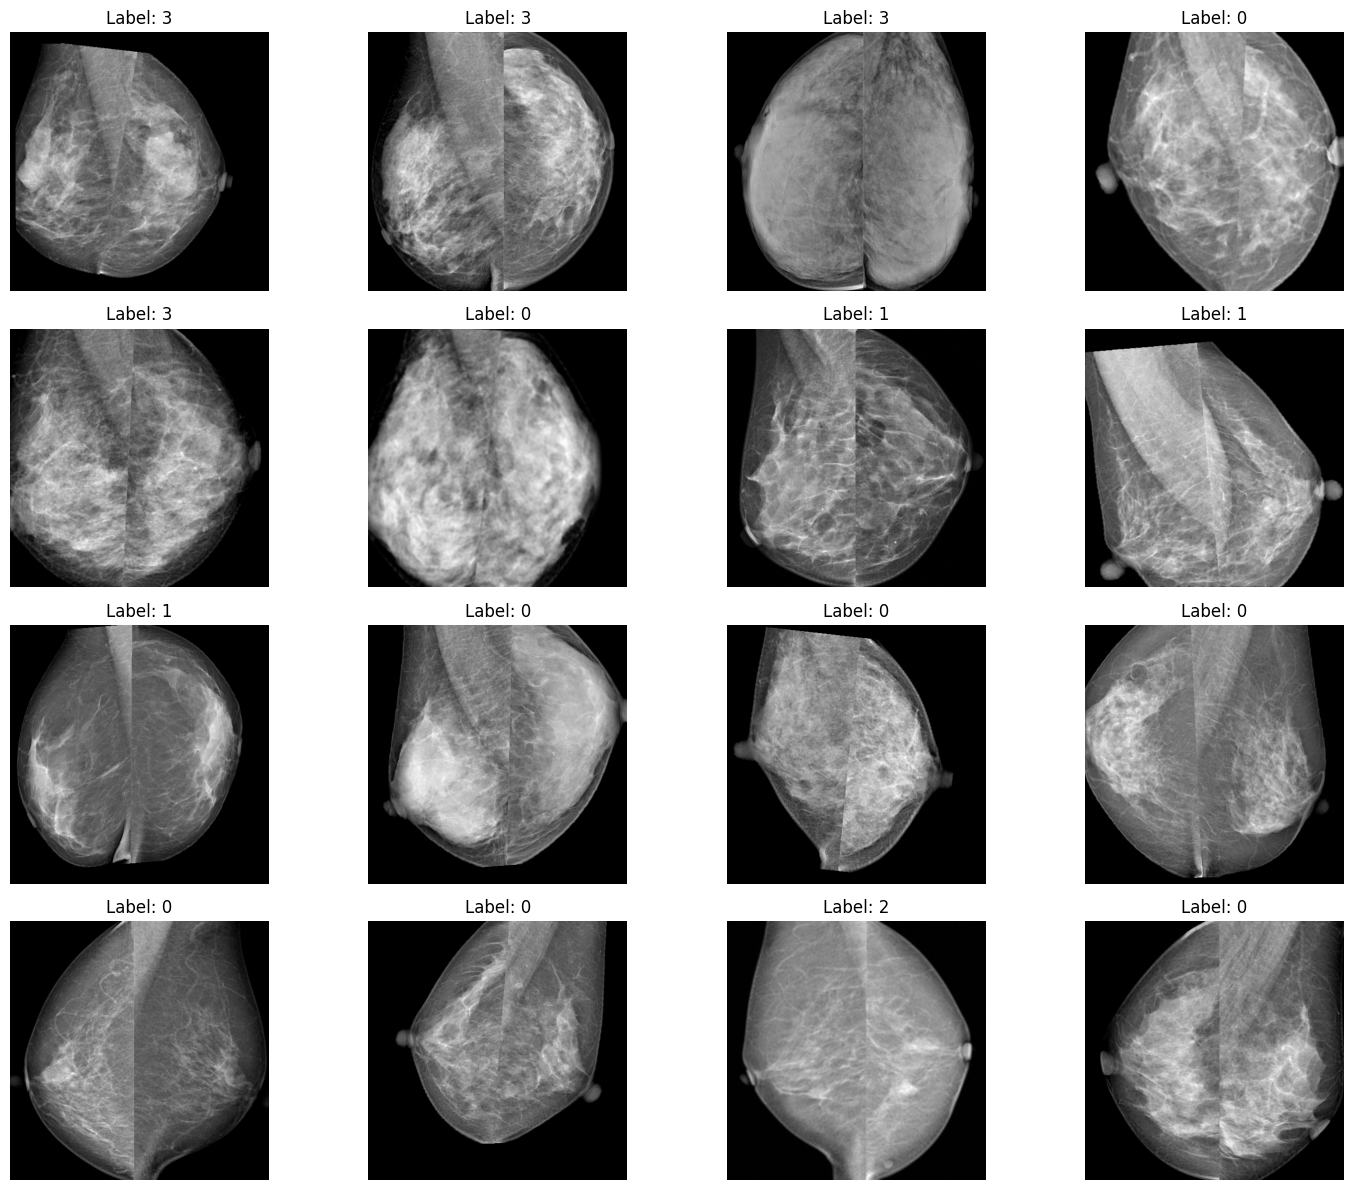


Visualizing validation samples:


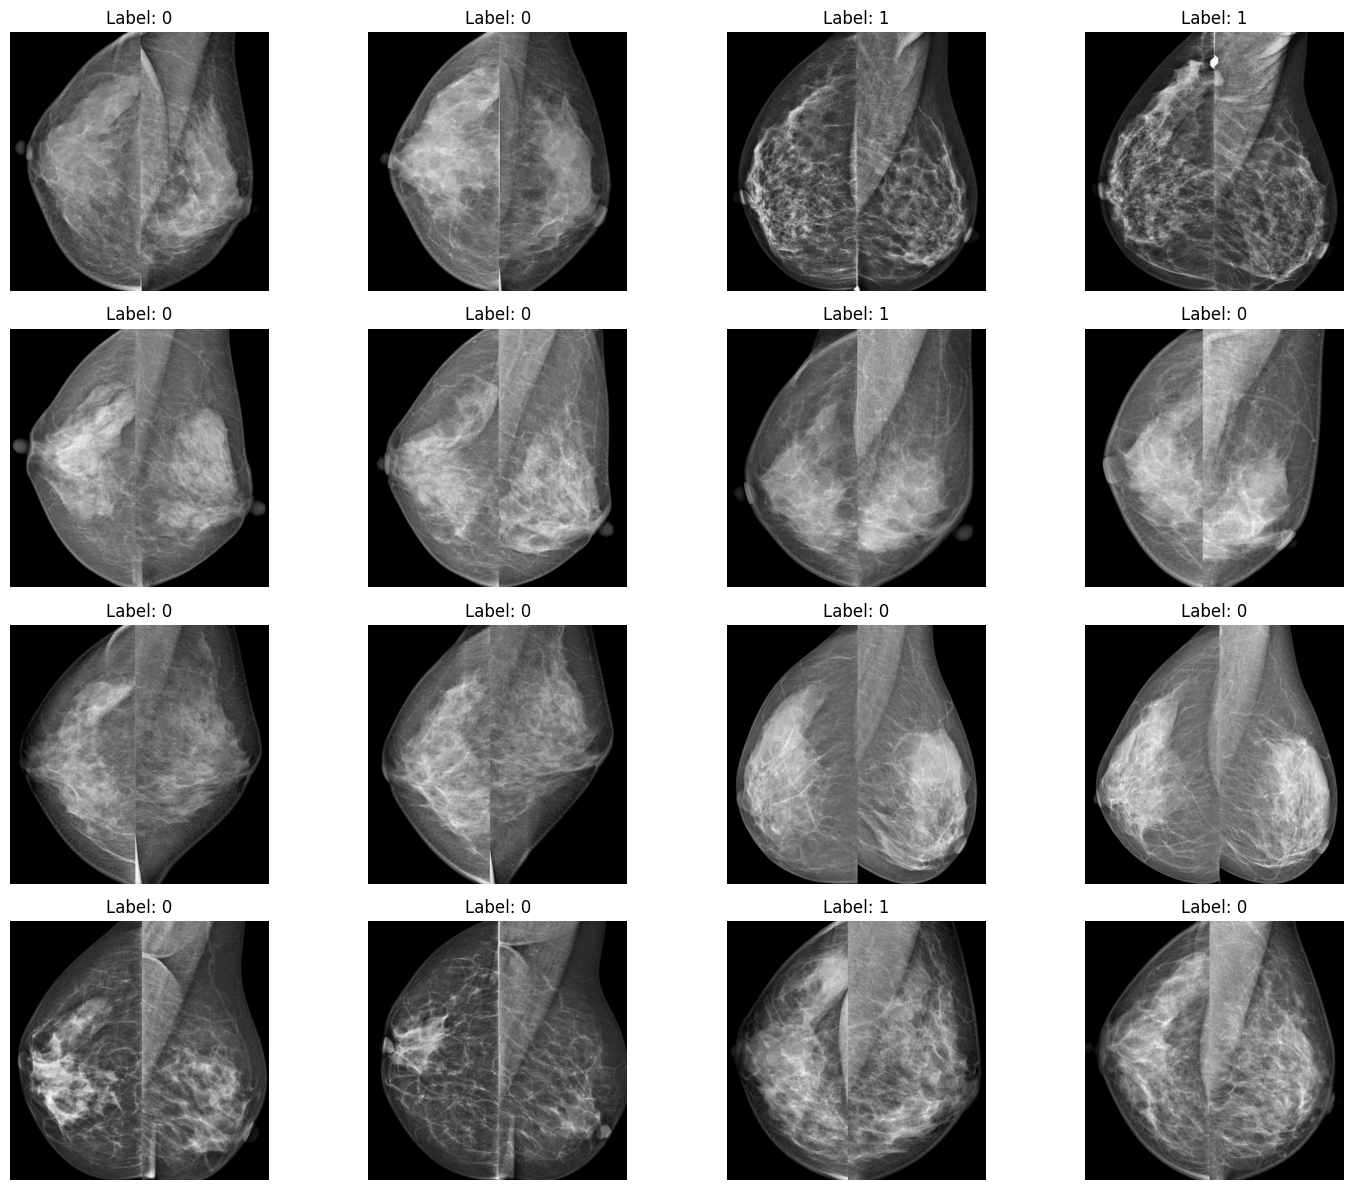

In [19]:
def visualize_batch(batch, n_cols=4, apply_inverse_normalize=True):
    """Visualize a batch of images with their labels"""
    _,images, labels = batch
    batch_size = images.shape[0]
    n_rows = int(np.ceil(batch_size / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows))
    axes = axes.ravel() if isinstance(axes, np.ndarray) else [axes]
    
    for i in range(batch_size):
        img = images[i]
        label = labels[i].item()
        
        # Inverse normalization if needed
        if apply_inverse_normalize:
            img = img.permute(1, 2, 0).numpy()
            # img=img*255
            img = (img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]) * 255
            img = img.mean(axis=2).astype(np.uint8)
        else:
            img = img.permute(1, 2, 0).numpy().astype(np.uint8)
        
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Label: {label}")
        axes[i].axis('off')
    
    # Hide empty subplots
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualize samples
print("Visualizing training samples:")
# Get a batch
train_batch = next(iter(train_loader))
visualize_batch(train_batch)

print("\nVisualizing validation samples:")
val_batch = next(iter(val_loader))
visualize_batch(val_batch)

In [20]:

from tqdm import tqdm
import torch.nn as nn
from torchvision import models
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from torch.optim import Adam
from sklearn.metrics import confusion_matrix, classification_report

In [21]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import recall_score
import torch
import numpy as np

def train_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for batch_idx, (image_path, images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.append(preds.detach().cpu())
        all_labels.append(labels.detach().cpu())
        
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    
    # Multi-class metrics for 5 classes
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    cls_report = classification_report(
        all_labels, 
        all_preds, 
        target_names=['BI-RADS 1', 'BI-RADS 2', 'BI-RADS 3', 'BI-RADS 4', 'BI-RADS 5'],
        digits=4,
        zero_division=0
    )
    conf_matrix = confusion_matrix(all_labels, all_preds)
    
    avg_loss = total_loss / len(train_loader)
    return avg_loss, accuracy, f1, cls_report, conf_matrix


def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for image_path, images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    
    # Multi-class metrics for 5 classes
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    
    # BI-RADS 5 (malignant) specific metrics - class index 4
    if 4 in all_labels and 4 in all_preds:
        malignant_recall = recall_score(all_labels == 4, all_preds == 4)
        f1_pos = f1_score(all_labels == 4, all_preds == 4)
    else:
        malignant_recall = 0.0
        f1_pos = 0.0
    
    cls_report = classification_report(
        all_labels, 
        all_preds, 
        target_names=['BI-RADS 1', 'BI-RADS 2', 'BI-RADS 3', 'BI-RADS 4', 'BI-RADS 5'],
        digits=4,
        zero_division=0
    )
    conf_matrix = confusion_matrix(all_labels, all_preds)
    
    avg_loss = total_loss / len(data_loader)
    return avg_loss, accuracy, f1, f1_pos, cls_report, conf_matrix, malignant_recall

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    """
    Multi-class Focal Loss implementation for BI-RADS 1–5 classification.
    Formula:
        FL = -alpha * (1 - p_t) ** gamma * log(p_t)
    Args:
        alpha (float, list, or tensor): Balancing factor for classes.
        gamma (float): Focusing parameter that reduces easy example weight.
        reduction (str): 'mean', 'sum', or 'none'
    """
    def __init__(self, alpha=None, gamma=2.0, reduction='mean', num_classes=5):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.num_classes = num_classes

        if alpha is None:
            # Equal weights for all classes
            self.alpha = torch.ones(num_classes)
        elif isinstance(alpha, (list, tuple)):
            assert len(alpha) == num_classes, "Alpha length must match num_classes"
            self.alpha = torch.tensor(alpha)
        else:
            # Same alpha for all classes
            self.alpha = torch.full((num_classes,), alpha)
        
    def forward(self, inputs, targets):
        """
        inputs: (N, C) — raw logits
        targets: (N,) — ground truth labels
        """
        if inputs.device != self.alpha.device:
            self.alpha = self.alpha.to(inputs.device)

        # Compute softmax over classes
        log_probs = F.log_softmax(inputs, dim=1)
        probs = torch.exp(log_probs)

        # Gather log-probabilities of the correct classes
        targets = targets.long()
        log_p = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        p_t = probs.gather(1, targets.unsqueeze(1)).squeeze(1)

        # Get alpha per target class
        alpha_t = self.alpha.gather(0, targets)

        # Compute focal loss
        loss = -alpha_t * (1 - p_t) ** self.gamma * log_p

        # Reduction
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss
criterion = FocalLoss(
        alpha=[0.06, 0.14, 0.3, 0.3, 0.2],  
        gamma=1.0,
        reduction='mean',
        num_classes=5
    )

In [23]:
class MultiClassAsymmetricFocalLoss(nn.Module):
    """
    Multi-class Asymmetric Focal Loss for auxiliary task (findings classification).
    """
    def __init__(self, num_classes=5, alpha=None, gamma=None, eps=1e-8):
        super().__init__()
        self.num_classes = num_classes
        self.eps = eps
        
        if alpha is None:
            alpha = [1.0] * num_classes
        alpha_tensor = torch.tensor(alpha, dtype=torch.float32)
        self.register_buffer('alpha', alpha_tensor / alpha_tensor.sum())
        
        if gamma is None:
            gamma = [2.0] * num_classes
        gamma_tensor = torch.tensor(gamma, dtype=torch.float32)
        self.register_buffer('gamma', gamma_tensor)
    
    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        alpha_t = self.alpha[targets]
        gamma_t = self.gamma[targets]
        focal_loss = alpha_t * (1 - pt.clamp(min=self.eps)) ** gamma_t * ce_loss
        return focal_loss.mean()


aux_alpha = [0.1, 0.1, 0.25, 0.25, 0.30]  
aux_gamma = [2.5, 2.0, 1.0, 1.0, 1.0]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = MultiClassAsymmetricFocalLoss(
    num_classes=5,
    alpha=aux_alpha,
    gamma=aux_gamma
).to(device)


In [24]:
import os
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, classification_report, confusion_matrix, cohen_kappa_score
)

def test_and_save_results(model, test_loader, device, model_name, dataset_name, save_dir):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0

    os.makedirs(save_dir, exist_ok=True)

    with torch.no_grad():
        for image_path, images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    # ---- Compute Metrics ----
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    recall_macro = recall_score(all_labels, all_preds, average='macro')
    qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')  # For ordinal BI-RADS
    
    target_names = ['BI-RADS 1', 'BI-RADS 2', 'BI-RADS 3', 'BI-RADS 4', 'BI-RADS 5']
    cls_report = classification_report(all_labels, all_preds, target_names=target_names, digits=4)
    conf_matrix = confusion_matrix(all_labels, all_preds)
    avg_loss = total_loss / len(test_loader)

    # ---- Save Confusion Matrix ----
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {dataset_name} ({model_name})')
    plt.tight_layout()
    cm_path = os.path.join(save_dir, f'{dataset_name}_confusion_matrix.png')
    plt.savefig(cm_path)
    plt.close()

    # ---- Save Results ----
    results_path = os.path.join(save_dir, f'{dataset_name}_results.txt')
    with open(results_path, 'w') as f:
        f.write(f'Model: {model_name}\n')
        f.write(f'Dataset: {dataset_name}\n')
        f.write(f'Loss: {avg_loss:.4f}\n')
        f.write(f'Accuracy: {accuracy:.4f}\n')
        f.write(f'F1 (macro): {f1_macro:.4f}\n')
        f.write(f'Recall (macro): {recall_macro:.4f}\n')
        f.write(f'Quadratic Weighted Kappa (QWK): {qwk:.4f}\n')
        f.write('\nClassification Report:\n')
        f.write(cls_report)
    print(f"Results saved to {save_dir}")

    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'recall_macro': recall_macro,
        'qwk': qwk,
        'conf_matrix': conf_matrix,
        'cls_report': cls_report
    }


In [25]:
import os
import gc
import time
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


# ============================================================
# METRICS
# ============================================================
def calculate_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred)
    return {'accuracy': acc, 'f1': f1, 'confusion_matrix': cm}


class GenericNet(nn.Module):

    def __init__(self, backbone_name, backbone_class, backbone_weights):
        super().__init__()
        self.num_classes = 5  
        self.backbone_name = backbone_name
        
        # Load pretrained backbone
        self.backbone = backbone_class(weights=backbone_weights)
        
        # Extract feature size and remove original classifier
        if 'efficientnet' in backbone_name:
            num_features = self.backbone.classifier[1].in_features
            self.backbone.classifier = nn.Identity()
        
        elif 'resnet' in backbone_name:
            num_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
        
        elif 'densenet' in backbone_name:
            num_features = self.backbone.classifier.in_features
            self.backbone.classifier = nn.Identity()
        
        elif 'convnext' in backbone_name:
            num_features = self.backbone.classifier[2].in_features
            self.backbone.classifier = nn.Identity()
        
        elif 'swin' in backbone_name:
            num_features = self.backbone.head.in_features
            self.backbone.head = nn.Identity()
        
        else:
            raise ValueError(f"Unsupported model type: {backbone_name}")
        
        self.global_pool = nn.AdaptiveAvgPool2d(1)

        hidden_size = 768 if 'swin' in backbone_name else 512
        
        # Unified classification head
        self.classifier = nn.Sequential(
            nn.Linear(num_features, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, self.num_classes)
        )


    def forward(self, x):
        """
        Forward pass
        Args:
            x: [batch_size, 3, 512, 512] input images
        Returns:
            logits: [batch_size, 3] class logits
        """
        features = self.backbone(x)
        
        # Handle different output formats
        if isinstance(features, tuple):
            features = features[0]
        
        # If spatial dimensions exist, apply global pooling
        if features.ndim == 4:  # [B, C, H, W]
            features = self.global_pool(features).flatten(1)
        
        # Classification
        logits = self.classifier(features)
        return logits


# ============================================================
# TRAIN + VALIDATION
# ============================================================
def train_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for _, images, labels in tqdm(train_loader, desc="Train", ncols=110):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        all_preds.append(outputs.argmax(1).cpu())
        all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    cls_report = classification_report(
        all_labels, all_preds,
        target_names=[f"BI-RADS {i+1}" for i in range(5)],
        digits=4, zero_division=0
    )
    conf_matrix = confusion_matrix(all_labels, all_preds)
    avg_loss = total_loss / len(train_loader)

    return avg_loss, acc, f1, cls_report, conf_matrix


@torch.inference_mode()
def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    for _, images, labels in tqdm(val_loader, desc="Validate", ncols=110):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item()
        all_preds.append(outputs.argmax(1).cpu())
        all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    cls_report = classification_report(
        all_labels, all_preds,
        target_names=[f"BI-RADS {i+1}" for i in range(5)],
        digits=4, zero_division=0
    )
    conf_matrix = confusion_matrix(all_labels, all_preds)
    avg_loss = total_loss / len(val_loader)

    return avg_loss, acc, f1, cls_report, conf_matrix


# ============================================================
# EARLY STOPPING
# ============================================================
class EarlyStopper:
    def __init__(self, patience=15, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.counter = 0

    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
            return False
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                return True
            return False
        else:
            self.best_score = score
            self.counter = 0
            return False




In [26]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score


@torch.inference_mode()
def test_and_save_results(model_class, model_weights_path, test_loader, device, save_dir, dataset_name="vindr"):

    result_dir = os.path.join(save_dir, dataset_name)
    os.makedirs(result_dir, exist_ok=True)

    model = model_class.to(device)
    model.load_state_dict(torch.load(model_weights_path, map_location=device))
    model.eval()

    all_preds, all_labels = [], []

    for _, images, labels in tqdm(test_loader, desc=f"Testing {dataset_name}", ncols=110):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    # Compute metrics
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    cls_report = classification_report(
        all_labels, all_preds,
        target_names=[f"BI-RADS {i+1}" for i in range(5)],
        digits=4, zero_division=0
    )
    cm = confusion_matrix(all_labels, all_preds)


    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap='Blues')
    plt.colorbar(im)
    ax.set_title(f'{dataset_name.upper()} Confusion Matrix', fontsize=14)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.set_xticks(np.arange(5))
    ax.set_yticks(np.arange(5))
    ax.set_xticklabels([f"B{i+1}" for i in range(5)])
    ax.set_yticklabels([f"B{i+1}" for i in range(5)])

    # Annotate cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')

    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, "confusion_matrix.png"), dpi=300)
    plt.close()


    report_path = os.path.join(result_dir, "classification_report.txt")
    with open(report_path, "w") as f:
        f.write(f"Dataset: {dataset_name.upper()}\n")
        f.write(f"Accuracy: {acc:.4f}\n")
        f.write(f"F1 Score (Macro): {f1:.4f}\n\n")
        f.write("Classification Report:\n")
        f.write(cls_report)
        f.write("\n\nConfusion Matrix:\n")
        f.write(np.array2string(cm))

    return acc, f1

In [ ]:

def train_generic_models(train_loader, val_loader, criterion, device):
    models_config = [
        # {
        #     'name': 'efficientnet_b3',
        #     'class': models.efficientnet_b3,
        #     'weights': models.EfficientNet_B3_Weights.DEFAULT
        # },
        
        # {
        #     'name': 'convnext_base',
        #     'class': models.convnext_base,
        #     'weights': models.ConvNeXt_Base_Weights.DEFAULT
        # },
    
        {
            'name': 'swin_v2_b',
            'class': models.swin_v2_b,
            'weights': models.Swin_V2_B_Weights.DEFAULT
        },
    ]

    for model_config in models_config:
        model_name = model_config['name']
        print(f"\n{'='*90}\nTraining {model_name}\n{'='*90}")

        model = GenericNet(
            backbone_name=model_name,
            backbone_class=model_config['class'],
            backbone_weights=model_config['weights']
        ).to(device)

        optimizer = AdamW([
        {'params': model.backbone.parameters(), 'lr': 1e-5},
        {'params': model.classifier.parameters(), 'lr': 5e-5}
    ], weight_decay=0.01)
        
        scheduler = ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,  
            patience=5,  
            min_lr=1e-6
        )
        early_stopper = EarlyStopper(patience=20)

        output_dir = f'Thesis_updated_results/Merged_birads_512/{model_name}'
        os.makedirs(output_dir, exist_ok=True)
        best_model_path = os.path.join(output_dir, 'best_model.pth')

        best_f1 = 0.0
        epochs = 60

        for epoch in range(epochs):
            start_time = time.time()
            train_loss, train_acc, train_f1, train_report, cm_train = train_epoch(model, train_loader, optimizer, criterion, device)
            val_loss, val_acc, val_f1, val_report, cm_val = evaluate(model, val_loader, criterion, device)
            scheduler.step(val_loss)

            print(f"\nEpoch {epoch+1}/{epochs} - {time.time()-start_time:.1f}s")
            print(f"LR: {optimizer.param_groups[0]['lr']:.2e}")
            print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
            print(f"Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f}")
            print(f"\nVal Confusion Matrix:\n{cm_val}")
            print(f"\nVal classification report:\n{val_report}")
            if val_f1 > best_f1:
                best_f1 = val_f1
                torch.save(model.state_dict(), best_model_path)
                print(f"New best model saved (F1={best_f1:.4f})")

            if early_stopper(val_f1) and (train_f1 > val_f1 + 0.35):
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

        print(f"\nTraining completed for {model_name}. Best F1: {best_f1:.4f}")
        
        test_and_save_results(
            model_class=model,
            model_weights_path=best_model_path,
            test_loader=val_loader,
            device=device,
            save_dir=output_dir,
            dataset_name="vindr_val"
        )
        test_and_save_results(
            model_class=model,
            model_weights_path=best_model_path,
            test_loader=test_loader,
            device=device,
            save_dir=output_dir,
            dataset_name="vindr_test"
        )
        
        test_and_save_results(
            model_class=model,
            model_weights_path=best_model_path,
            test_loader=inbreast_loader,
            device=device,
            save_dir=output_dir,
            dataset_name="inbreast"
        )
        del model, optimizer, scheduler
        
train_generic_models(train_loader, val_loader, criterion, device)


Training swin_v2_b


Train:   0%|                                                                          | 0/441 [00:00<?, ?it/s]

In [ ]:
fffffff

In [ ]:
print("h1")